# Exercises XP Gold: Guided Student Notebook

This guided notebook follows the **exercises on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included when a concept is important for intuition or transfer to other AI topics.


## Exercises content

You will learn how neural networks make predictions using forward propagation, how backpropagation adjusts weights to minimize errors, how activation functions impact performance, how to manually compute and implement gradient descent, and how to build and train a simple neural network from scratch.

You will create a multi-layer perceptron for binary classification, a Python implementation of activation functions, a forward-propagation model for house prices, a model that updates weights using gradient descent, and a simple training loop.


## Exercise 1: Implementing a Multi-Layer Perceptron (MLP) from Scratch

**As stated in the exercise**  
Task: Build a multi-layer perceptron for a binary classification problem using NumPy. The model has one hidden layer with three neurons, uses ReLU activation for hidden layers and Sigmoid for the output layer, and computes forward propagation.  

Steps: Define the architecture with an input layer of two neurons, a hidden layer of three neurons with ReLU, and an output layer of one neuron with Sigmoid. Implement forward propagation using weighted sums and activation functions. Predict outputs for two inputs: first case with input values of two and three. Second case with input values of one and five.

**Guidance**  
Keep the computation vectorized. Use shapes (N, 2) for inputs, (2, 3) and (3, 1) for weight matrices, and broadcasted biases with shapes (3,) and (1,). ReLU is \(\max(0, x)\). Sigmoid is \(\sigma(x)=1/(1+e^{-x})\).

**Learning point**  
Hidden layers re-map inputs into a representation where a linear readout solves a complex decision. ReLU preserves positive evidence and truncates negative evidence. Sigmoid squashes to probabilities for binary outputs.

![image.png](https://github.com/user-attachments/assets/8a6c5e25-c143-42c0-8996-557c912e40cf)


In [4]:
# PREFILLED: just execute
import numpy as np

rng = np.random.default_rng(42)

def relu(x):
    """ReLU activation. PREFILLED: just execute."""
    return np.maximum(0.0, x)

def sigmoid(x):
    """Sigmoid activation. PREFILLED: just execute."""
    return 1.0 / (1.0 + np.exp(-x))

# Random but fixed parameters for reproducibility
W1 = rng.normal(scale=0.1, size=(2, 3))  # input->hidden
b1 = rng.normal(scale=0.1, size=(3,))    # hidden bias
W2 = rng.normal(scale=0.1, size=(3, 1))  # hidden->output
b2 = rng.normal(scale=0.1, size=(1,))    # output bias

print("Shapes:", W1.shape, b1.shape, W2.shape, b2.shape)

Shapes: (2, 3) (3,) (3, 1) (1,)


In [5]:
def mlp_forward(X):
    # compute Z1
    Z1 = np.dot(X, W1) + b1
    # apply ReLU to get A1
    A1 = relu(Z1)
    # compute Z2
    Z2 = np.dot(A1, W2) + b2
    # apply Sigmoid to get Yhat in (N, 1)
    Yhat = sigmoid(Z2)
    return Yhat.ravel() # for convenience

In [6]:
import numpy as np

# Predict for the two cases and print the outputs
# Case 1: input values of two and three
# Case 2: input values of one and five

X = np.array([[2.0, 3.0],
              [1.0, 5.0]], dtype=float)
yhat = mlp_forward(X)
print({"case1": float(yhat[0]), "case2": float(yhat[1])})

{'case1': 0.49406115512561966, 'case2': 0.4907000760284681}


**To-Do:** Briefly interpret your two probabilities. Explain whether each case is predicted as class 0 or class 1 using a 0.5 threshold and why.


## Exercise 2: Implementing Backpropagation with Gradient Descent

**As stated in the exercise**  
Task: Manually compute backpropagation and update weights using gradient descent for predicting student exam scores.  
Given data. Study hours with a value of six. Previous test score with a value of seventy five. Initial weights with values of zero point four for study hours and zero point six for previous score. Bias with a value of five. Actual exam score with a value of eighty five. Learning rate of zero point zero one.  

Steps: Compute the predicted exam score using the weighted sum formula. Calculate the loss using the mean squared error formula. Compute the gradients for the weights and update them using gradient descent. Interpret the results and observe how much the weights change.

**Guidance**  
Use a linear model \(y = w_1 x_1 + w_2 x_2 + b\). The mean squared error for a single example is \(L = \tfrac{1}{2}(y_{true}-y)^2\). Gradients are \(\partial L/\partial w = -(y_{true}-y) x\) and \(\partial L/\partial b = -(y_{true}-y)\).

**Learning point**  
The gradient vector points to the direction of steepest increase. Subtracting the gradient reduces the loss locally. The learning rate sets the step magnitude.

![image.png](https://github.com/user-attachments/assets/4f5c46d3-707d-4291-aab7-2269b291d531)

In [7]:
# PREFILLED: just execute
import numpy as np

x = np.array([6.0, 75.0])  # study hours, previous test score
w = np.array([0.4, 0.6])   # initial weights
b = 5.0                    # bias
y_true = 85.0
lr = 0.01

def predict(x, w, b):
    return float(np.dot(x, w) + b)

def mse(y, y_true):
    return 0.5 * (y_true - y) ** 2

In [8]:
# To-Do: compute y_pred, loss, gradients, and updated parameters
# y_pred = ...
# loss = mse(y_pred, y_true)
# grad_w = ...
# grad_b = ..
# w_new = w - lr * grad_w
# b_new = b - lr * grad_b
# print({"y_pred": y_pred, "loss": float(loss), "w_new": w_new, "b_new": b_new})

**To-Do:** Describe the sign of each gradient and the qualitative effect on each parameter after one update.


## Exercise 3:Comparing Activation Functions for Neural Networks

**As stated in the exercise**  
Task: Implement and compare three activation functions: Step, Sigmoid, and ReLU. Create a graph that visualizes Sigmoid and ReLU. Compare behaviors: identify which function gives only binary outputs, which transitions smoothly, and which sets negative values to zero but keeps positive values unchanged. Answer why ReLU is common in deep models, why Sigmoid suits binary classification outputs, and what weaknesses the Step function has.

**Guidance**  
Define each function for NumPy arrays. Plot Sigmoid and ReLU on the same axes for inputs from −10 to 10.

**Learning point**  
ReLU supports deep optimization with stable gradients for positive inputs and sparse activation. Sigmoid saturates and can cause vanishing gradients inside deep hidden stacks, but is suitable at the output for probabilities in binary tasks.



In [9]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-10, 10, 400)

In [10]:
# To-Do: implement step, sigmoid, and relu
# def step(x):
#     return ...
# def sigmoid(x):
#     return ...
# def relu(x):
#     return ...

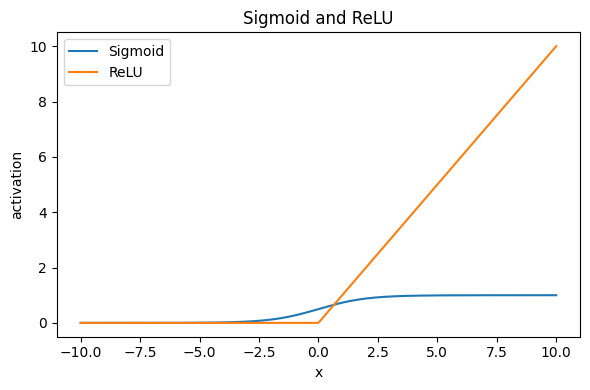

In [11]:
# Pre-filled: compute values and plot Sigmoid and ReLU on a single chart
ys_sig = sigmoid(xs)
ys_relu = relu(xs)
plt.figure(figsize=(6,4))
plt.plot(xs, ys_sig, label="Sigmoid")
plt.plot(xs, ys_relu, label="ReLU")
plt.title("Sigmoid and ReLU")
plt.legend()
plt.xlabel("x")
plt.ylabel("activation")
plt.tight_layout()
plt.show()

**To-Do:** Answer in full sentences. Identify the binary-only function, the smooth transition function, and the function that zeroes negatives while passing positives unchanged. Explain in one paragraph why ReLU is dominant in deep models and why Sigmoid is used at the output for binary tasks. State one weakness of the Step function.


## Exercise 4: Forward Propagation in a Deep Neural Network

**As stated in the exercise**  
Task: Manually compute forward propagation for a three-layer neural network predicting house prices.  
Given data. Inputs: square footage with a value of two thousand and number of bedrooms with a value of three. Layer one weights and bias: first weight 0.5, second weight 0.7, first bias ten thousand. Layer two weights and bias: first weight 0.6, second weight 0.8, second bias twenty thousand. Output layer weight and bias: weight 1.2 and bias thirty thousand. Activation function is ReLU.  

Steps: Compute the output of the first layer using the weighted sum and ReLU. Compute the output of the second layer similarly. Compute the final prediction using the weighted sum at the output layer. Interpret the predicted house price.

**Guidance**  
Assumption for this notebook. Each intermediate layer is a single neuron. The second layer consumes the previous layer activation. Under this assumption, the second layer formula reduces to a single effective weight \(w_2^{eff} = 0.6 + 0.8\) on the previous activation because only one input is present at that stage.

**Learning point**  
Layer composition stacks affine maps and ReLU. When a layer has a single input, multiple scalar weights collapse into an equivalent single weight. Feature scaling dominates numeric magnitudes.



In [12]:
# PREFILLED: just execute
def relu_scalar(x: float) -> float:
    return x if x > 0.0 else 0.0

x1 = 2000.0  # square footage
x2 = 3.0     # number of bedrooms

# Layer 1 parameters
w11, w12 = 0.5, 0.7
b1 = 10000.0

# Layer 2 parameters (effective single-input interpretation; see guidance)
w21, w22 = 0.6, 0.8  # collapse to w2_eff = w21 + w22
b2 = 20000.0

# Output layer parameters
w_out = 1.2
b_out = 30000.0

In [13]:
# To-Do: compute forward propagation step by step
# z1 = ...
# a1 = relu_scalar(z1)
# w2_eff = ...
# z2 = w2_eff * a1 + b2
# a2 = relu_scalar(z2)
# y = ...
# print({"z1": z1, "a1": a1, "z2": z2, "a2": a2, "prediction": y})

**To-Do:** Interpret the final number as a house price. Explain the effect of large biases on the magnitude of the prediction.


## Exercise 5: Training a Neural Network with Forward and Backward Propagation

**As stated in the exercise**  
Task: Train a simple neural network to predict a student’s exam score using gradient descent.  

Steps: Initialize input values for study hours and previous test score. Initialize weights and bias. Compute forward propagation to predict the exam score. Compute the error between prediction and actual score. Compute gradients for weights and bias. Update the weights and bias using gradient descent. Print updated weights and bias after one training iteration.

**Guidance**  
Use a linear model for clarity. A single update demonstrates the mechanism. Extend to multiple iterations if you want to observe convergence.

**Learning point**  
A training loop alternates prediction, loss computation, gradient calculation, and parameter updates. This template generalizes to deep networks with automatic differentiation.


In [14]:
# PREFILLED: just execute
import numpy as np

# Example inputs
x = np.array([5.0, 70.0])  # study hours, previous score
w = np.array([0.3, 0.5])   # initial weights
b = 8.0                    # bias
y_true = 90.0              # target
lr = 0.01

def forward_linear(x, w, b):
    return float(np.dot(x, w) + b)

In [15]:
# To-Do: perform one training iteration
...
# print({"y_pred": y_pred, "loss": float(loss), "w": w, "b": b})

## Conclusion

You have practiced multi-layer perceptrons, implemented activation functions, performed forward and backward propagation, and applied gradient descent to train a simple model. For additional practice, try replacing ReLU with Tanh or changing the learning rate to explore stability and convergence behavior.
